# Extended Data Figure 10

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
import os
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm
import math
import scipy.stats as stats

from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# Extended Data Figure 10:
# Load data:
os.chdir('../Fig. 5')
data2_R39H12_barfixation = pd.read_csv('fig5_R39H12_barfixation.csv')
os.chdir('../ED Fig. 10')
data3_R59E08_R42F06_barfixation = pd.read_csv('edfig10_R59E08_R42F06_barfixation.csv')


# Apply inclusion criteria:
def include_exclude(data, forward_min, min_trials, r_dev=None):
    """ Apply inclusion criteria to preprocessed dataset
    
        :data: pandas dataframe.
        :forward_min: the minimal average forward walking velocity (cm/s) for which a trial is included.
        :r_dev: the maximal average rotational velocity (degrees/s) over all included trials for which a fly is included (only used in fixation experiments).
        :min_trials: the minimal number of trials for which a fly is included.
        
        :returns: only the included trials and flies.
    """
    
    # Calculate mean forward speed per fly per trial
    d = data
    mean_forward = d.groupby(['flyname', 'trial']).forward.mean()
    d = d.merge(mean_forward, on=['flyname', 'trial'], suffixes=('', '_mean'))

    ###################### INCLUSION CRITERION (mean forward velocity) ######################
    fast_data = d.query("forward_mean >= @forward_min")
    
    curr_data = fast_data
    n_trials = curr_data.groupby(['flyname']).trial.unique().str.len()
    curr_data = curr_data.merge(n_trials, on='flyname', suffixes=('', 's_n'))
    s = curr_data
    
    mean_rotation = s.groupby(['flyname']).rotation.mean()
    s = s.merge(mean_rotation, on=['flyname'], suffixes=('', '_mean'))

    if r_dev != None:
        ######### INCLUSION CRITERION (average rotation deviation from 0 degree) ############
        straight_flies = s.query("rotation_mean <= (0 + @r_dev) and rotation_mean >= (0 - @r_dev)")
    else:
        straight_flies = s

    ##################### INCLUSION CRITERION (minimal number of trials) ####################
    included_data = straight_flies.query("trials_n >= @min_trials")

    data_included = included_data.drop(columns=['forward_mean', 'rotation_mean'])
    
    return data_included

data2_R39H12_barfixation_included = include_exclude(data = data2_R39H12_barfixation, forward_min = 0.40, min_trials = 50, r_dev = 10)
data3_R59E08_R42F06_barfixation_included = include_exclude(data = data3_R59E08_R42F06_barfixation, forward_min = 0.40, min_trials = 20, r_dev = 10)

In [3]:
# Sort datasets: 
def order_dataset(data, columns_to_keep, index_columns):
    """ Order dataset based on genotypes and remove unnecessary columns
    
    :data: dataset with all included flies and trials
    :columns_to_keep: list of all columns that should be kept
    :index_columns: list of all columns that should be used as index
    
    :return: ordered dataset
    """
    
    data = data.loc[:, columns_to_keep]
    genotype_list = {
        'R39H12': 1,
        'R59E08_R42F06': 2,
        'GluCla_RNAi': 3,
        'R39H12>GluCla_RNAi': 4,
        'R59E08_R42F06>GluCla_RNAi': 5,
        'NMDA_R1_RNAi': 6,
        'R39H12>NMDA_R1_RNAi': 7,
    }
    
    data.loc[:,'ordered_index'] = data['genotype'].map(genotype_list)
    indices = ['ordered_index'] + index_columns
    data_ordered = data.set_index(indices).sort_values(by=indices) 
    
    return data_ordered

# Sort data for Extended Data Figure 10b:
data2_R39H12_barfixation_ordered = order_dataset(data2_R39H12_barfixation_included, columns_to_keep = ['genotype', 'flyname', 'trial', 
                                        'time', 'forward', 'rotation', 'bar_angle', 'trials_n'], index_columns = ['genotype', 'flyname', 
                                                                                         'trial', 'time'])

# Sort remaining data for Extended Data Figure 10:
data3_R59E08_R42F06_barfixation_ordered = order_dataset(data3_R59E08_R42F06_barfixation_included, columns_to_keep = ['genotype', 'flyname', 'trial', 
                                        'time', 'forward', 'rotation', 'bar_angle', 'trials_n'], index_columns = ['genotype', 'flyname', 
                                                                                         'trial', 'time'])

In [4]:
# Plot example traces of bar angle:
def get_min_fly_n(data):
    """
    Calculate the minimal number of flies belonging to a unique genotype in the dataset.
    """
    df = data.reset_index()
    n_flies = []
    for gt in df.genotype.unique():
        n_flies.append(len(df.query("genotype == @gt").flyname.unique()))
    return np.min(n_flies)

def plot_bar_angle_traces(data, genotype, show_labels, path_name, alpha):
    """
    Plot and save the trajectory traces of the bar angle over time.
    data: dataset with all genotypes that need to be plotted.
    genotype: string, the genotype to plot currently.
    show_labels: boolean, whether to show axis labels.
    path_name: string, indicate where the plot needs to be saved. 
    """
    min_fly_n = get_min_fly_n(data)
    min_trial_n = data.reset_index().trials_n.min()
    
    flies = list(data.reset_index().query("genotype == @genotype").flyname.unique()[:min_fly_n])

    ds = data.query("genotype == @genotype and trial <= @min_trial_n and flyname == @flies").reset_index()

    x = ds.time
    y = ds.bar_angle

    # Create a set of line segments so that we can plot them individually
    # This creates the points as a N x 1 x 2 array so that we can stack points
    # together easily to get the segments. The segments array for line collection
    # needs to be (numlines) x (points per line) x 2 (for x and y)

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segs = np.concatenate([points[:-1], points[1:]], axis=1)

    # Mask the line elements that cross vertically. The bar crosses the midline behind the fly here (the 180-degree / -180-degree border)
    mask = np.full_like(segs, 0, dtype=bool)

    for i in range(len(segs)):
        if (abs(segs[i,0,1] - segs[i,1,1]) > 180):
            mask[i,:,:] = [[True, True], [True, True]]

        # when the two time values of a segment are not 0.05s apart, this means the new values are from a new trial or fly. The connecting horizontal line should also not be drawn.
        if (abs(segs[i,0,0] - segs[i,1,0]) > 5):
            mask[i,:,:] = [[True, True], [True, True]]

    segs = np.ma.masked_where((mask), segs)

    fig, ax = plt.subplots(figsize=(5,5))

    ax.set_xlim(0, 20)
    ax.set_ylim(-180, 180)
    ax.set_yticks([-180, -90, 0, 90, 180])

    line_segments = LineCollection(segs, linewidth=0.5, color="k", alpha = alpha)

    ax.add_collection(line_segments)
    
    ax.set_title(genotype)
    ax.set_ylabel('Bar position (°)')
    ax.set_xlabel('Time (s)')
    
    if show_labels == False:
        plt.axis('off')
    
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    
    #plt.savefig(path_name, bbox_inches=extent)
    
    return

# Divide the bar_angle range [-180 to  +180 degrees] into 72 bins spanning 5 degrees each, and count for every trial how many measurements
# fall within each bin. The total hist_count for each trial will sum to the 400 measurements which make up each trial.
def bar_angle_histogram_counts(data, measurement_range_min, measurement_range_max, bins):  
    """
    Count the number of values per value that fall in each defined histogram bin.
    data: dataset
    measurement_range_min: minimal value of the measurement range (will be lower bound of histogram).
    measurement_range_max: maximal value of the measurement range (will be upper bound of histogram).
    bins: number of bins to divide the measurement_range in. 
    """
    hist_counts = pd.DataFrame(columns=['ordered_index', 'genotype', 'flyname', 'trial', 'hist_counts'])

    for i, fly in enumerate(data.flyname):
        hist_count = np.histogram(data.loc[i, 'bar_angle'][:], range = (measurement_range_min, measurement_range_max), bins = bins)[0]
        trial = data.loc[i, 'trial']
        genotype = data.loc[i, 'genotype']
        ordered_index = data.loc[i, 'ordered_index']
        temp = pd.DataFrame([[ordered_index, genotype, fly, trial, hist_count]], columns=(['ordered_index', 'genotype', 'flyname', 'trial', 'hist_counts']))
        hist_counts = hist_counts.append(temp, ignore_index=True)
    return hist_counts

def expand_hist_counts(data, measurement_range_min, measurement_range_max, bins):
    """
    data: dataset
    measurement_range_min: minimal value of the measurement range (will be lower bound of histogram).
    measurement_range_max: maximal value of the measurement range (will be upper bound of histogram).
    bins: number of bins to divide the measurement_range in. 
    
    Give the same values as used in the bar_angle_histogram_counts function.
    """
    
    hist_counts_flyagg = data.set_index(['ordered_index', 'genotype', 'flyname', 'trial'])
    hist_counts_flyagg = hist_counts_flyagg.groupby(['ordered_index', 'genotype', 'flyname']).agg({'hist_counts':list})
    hist_counts_flyagg = hist_counts_flyagg.reset_index()

    mean_bin_counts = pd.DataFrame(columns = (['ordered_index', 'genotype', 'flyname', 'mean_bin_count']))

    for i, fly in enumerate(hist_counts_flyagg.flyname):
        flydata = hist_counts_flyagg.loc[i, 'hist_counts']
        mean_bin_count = [float(sum(col))/len(col) for col in zip(*flydata)] # average over trials (rows) for all bins (columns).
        ordered_index = hist_counts_flyagg.loc[i, 'ordered_index']
        genotype = hist_counts_flyagg.loc[i, 'genotype']
        temp = pd.DataFrame([[ordered_index, genotype, fly, mean_bin_count]], columns=(['ordered_index', 'genotype', 'flyname', 'mean_bin_count']))
        mean_bin_counts = mean_bin_counts.append(temp, ignore_index=True)
    mean_bin_counts
    
    bin_size = (measurement_range_max - measurement_range_min) / bins
    
    mean_bin_counts_long = mean_bin_counts.explode('mean_bin_count')
    bin_midpoint_ = [*np.arange((measurement_range_min + 0.5 * bin_size), (measurement_range_max + 0.5 * bin_size), bin_size)] # midpoint values of all bins
    mean_bin_counts_long['bin_midpoint'] = np.resize(bin_midpoint_,len(mean_bin_counts_long))
    mean_bin_counts_long.mean_bin_count = mean_bin_counts_long.mean_bin_count.astype(float)
    mean_bin_counts_long.bin_midpoint = mean_bin_counts_long.bin_midpoint.astype(float)
    
    return mean_bin_counts_long

# Plot probability densities:
def plot_density(data, genotypes, colors, path_name):
    """
    Plot and save the density values of the bar angle for each genotype of interest.
    data: dataset with all genotypes that need to be plotted.
    genotypes: list of strings, the genotypes to plot.
    colors: list of strings corresponding to the colors for each genotype.
    path_name: string, indicate where the plot needs to be saved. 
    """
    data_mean = data.groupby(['genotype', 'bin_midpoint']).mean().reset_index() 
    data_sem = data.groupby(['genotype', 'bin_midpoint']).sem().reset_index()
    
    fig, ax = plt.subplots(1,1)

    for idx, gt in enumerate(genotypes):
        x = data_mean.query("genotype == @gt").bin_midpoint
        y = data_mean.query("genotype == @gt").probability_density
        err = data_sem.query("genotype == @gt").probability_density
        ax.plot(x, y, color=colors[idx], label=genotypes[idx])
        ax.fill_between(x, y-err, y+err, color=colors[idx], alpha=0.1)
    ax.set_ylabel('Probability density (% per °)')
    ax.set_xlabel('Bar position (°)')
    sns.despine()
    ax.axvline(-30, linestyle=':', color='k')
    ax.axvline(30, linestyle=':', color='k')
    ax.set_xticks([-180, -90, 0, 90, 180])
    ax.set_yticks([0.2, 0.4, 0.6, 0.8])

    plt.legend(frameon=False);
    #plt.savefig(path_name)
    
# We calculate the probability of finding the bar in the 60°-frontal window for each trial seperately,
# and then average over flies and genotypes.

def fixation_in_front(data, measurement_range_min, measurement_range_max, bins):
    """
    data: dataset
    measurement_range_min: minimal value of the measurement range (will be lower bound of histogram).
    measurement_range_max: maximal value of the measurement range (will be upper bound of histogram).
    bins: number of bins to divide the measurement_range in. 
    
    Give the same values as used in the bar_angle_histogram_counts function.
    """
    
    bin_size = (measurement_range_max - measurement_range_min) / bins
    bin_midpoint_ = [*np.arange((measurement_range_min + 0.5 * bin_size), (measurement_range_max + 0.5 * bin_size), bin_size)] # midpoint values of all bins
    
    hist_counts_per_trial_long = data.explode('hist_counts')
    hist_counts_per_trial_long['bin_midpoint'] = np.resize(bin_midpoint_,len(hist_counts_per_trial_long))
    hist_counts_per_trial_long.hist_counts = hist_counts_per_trial_long.hist_counts.astype(float)
    hist_counts_per_trial_long.bin_midpoint = hist_counts_per_trial_long.bin_midpoint.astype(float)
    
    prob_density = hist_counts_per_trial_long.query("bin_midpoint in [-27.5, -22.5, -17.5, -12.5, -7.5, -2.5, 2.5, 7.5, 12.5, 17.5, 22.5, 27.5]")

    # divide hist_counts by 400 to make all values of one trial add up to 1 instead of 400.
    prob_density['prob_per_bin'] = prob_density.hist_counts / 400 

    fixation_in_front = pd.DataFrame(prob_density.groupby(['ordered_index','genotype','flyname', 'trial']).prob_per_bin.sum())
    fixation_in_front = fixation_in_front.rename({"prob_per_bin":"fixation_in_front"}, axis = 1)
    fixation_in_front_flymeans = pd.DataFrame(fixation_in_front.reset_index().groupby(['ordered_index','genotype','flyname']).fixation_in_front.mean())
    fixation_in_front_plotting = fixation_in_front_flymeans.reset_index()
    
    fixation_in_front_plotting["percent"] = fixation_in_front_plotting.fixation_in_front * 100
    
    return fixation_in_front_plotting


In [5]:
# Extended Data Figure 10 (bar fixation closed-loop experiment,
# with T4/T5 R59E08-AD; R42F06-DBD, UAS-GluCla_RNAi, UAS-NMDA_R1_RNAi):

print("Bar fixation R59E08_R42F06")
for gt in data3_R59E08_R42F06_barfixation_ordered.reset_index().genotype.unique():
    print(gt, "n =", len(data3_R59E08_R42F06_barfixation_ordered.reset_index().query("genotype == @gt").flyname.unique()))
    

Bar fixation R59E08_R42F06
R59E08_R42F06 n = 11
GluCla_RNAi n = 14
R59E08_R42F06>GluCla_RNAi n = 14


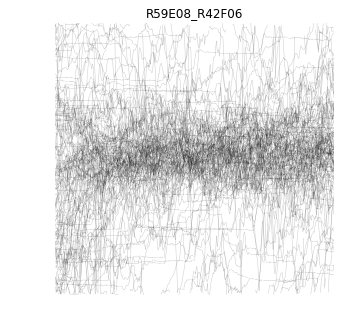

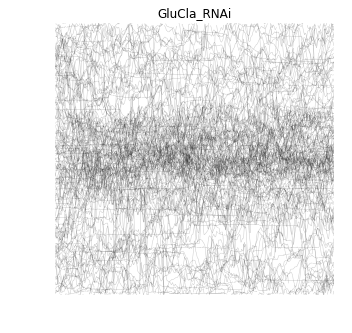

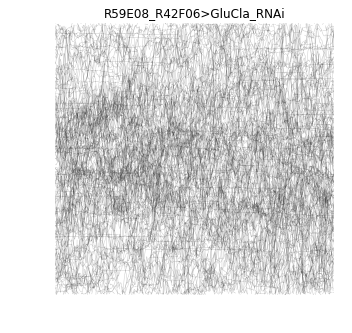

In [6]:
# Extended Data Figure 10e, top:
data3_R59E08_R42F06_barfixation_tracesplot = data3_R59E08_R42F06_barfixation_ordered

plot_bar_angle_traces(data=data3_R59E08_R42F06_barfixation_tracesplot, genotype='R59E08_R42F06', show_labels=False, path_name='edfig10e_traces_R59E08_R42F06.png', alpha = 0.2)
plot_bar_angle_traces(data=data3_R59E08_R42F06_barfixation_tracesplot, genotype='GluCla_RNAi', show_labels=False, path_name='edfig10e_traces_GluCla_RNAi.png.png', alpha = 0.2)
plot_bar_angle_traces(data=data3_R59E08_R42F06_barfixation_tracesplot, genotype='R59E08_R42F06>GluCla_RNAi', show_labels=False, path_name='edfig10e_traces_R59E08_R42F06>GluCla_RNAi.png', alpha = 0.2)

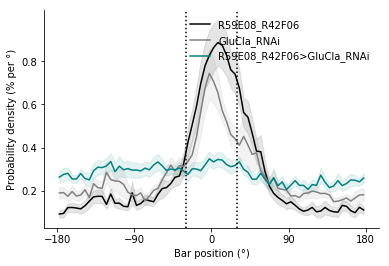

In [7]:
# Extended Data Figure 10 e bottom:
data3_R59E08_R42F06_barfixation_densityplots = data3_R59E08_R42F06_barfixation_ordered.groupby(['ordered_index','genotype','flyname', 'trial', 'trials_n']).agg({'bar_angle':list})
data3_R59E08_R42F06_barfixation_densityplots = data3_R59E08_R42F06_barfixation_densityplots.reset_index()

data3_R59E08_R42F06_barfixation_hist_counts = bar_angle_histogram_counts(data3_R59E08_R42F06_barfixation_densityplots, -180, 180, 72)

data3_R59E08_R42F06_barfixation_hist_counts_expanded = expand_hist_counts(data3_R59E08_R42F06_barfixation_hist_counts, -180, 180, 72)

# To go from counts per 5°-bin to probability densities in % per °, we devide the values by 20. Since 400 values per trial
# divided by 4 gives percentages for each 5°-bin, and dividing by 5 gives the values per °. 
data3_R59E08_R42F06_barfixation_hist_densities = data3_R59E08_R42F06_barfixation_hist_counts_expanded
data3_R59E08_R42F06_barfixation_hist_densities.mean_bin_count = data3_R59E08_R42F06_barfixation_hist_densities.mean_bin_count / 20
data3_R59E08_R42F06_barfixation_hist_densities = data3_R59E08_R42F06_barfixation_hist_densities.rename(columns={'mean_bin_count': 'probability_density'})

plot_density(data3_R59E08_R42F06_barfixation_hist_densities, genotypes = ['R59E08_R42F06', 'GluCla_RNAi', 'R59E08_R42F06>GluCla_RNAi'], colors = ['k', 'grey', 'teal'], path_name = 'edfig10e_bottom.pdf')

/anaconda2/envs/PyClamp/lib/python3.7/site-packages/ipykernel_launcher.py:185: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


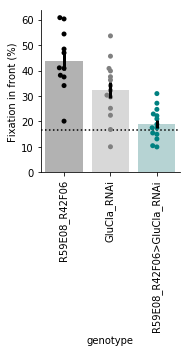

In [8]:
# Extended Data Figure 10f:
data3_R59E08_R42F06_barfixation_fixation_in_front = fixation_in_front(data3_R59E08_R42F06_barfixation_hist_counts, -180, 180, 72)

bpal = ['k', 'gray', 'teal']
dotsize = 5

fig, ax = plt.subplots(1, 1, figsize=(2.75, 5))
a = sns.swarmplot(x="genotype", y="percent", hue="genotype", palette=bpal,
                  data=data3_R59E08_R42F06_barfixation_fixation_in_front, dodge=False, alpha=1.0, size=dotsize)
a.legend_.remove()
a.axhline(16.6667, color = 'k', linestyle=':')
b = sns.barplot(x="genotype", y="percent", hue="genotype", palette=bpal,
                data=data3_R59E08_R42F06_barfixation_fixation_in_front, dodge=False, ci=None, alpha=.3);
b.errorbar(x=np.arange(0, len(data3_R59E08_R42F06_barfixation_fixation_in_front.genotype.unique())),y=data3_R59E08_R42F06_barfixation_fixation_in_front.groupby(['genotype'], sort=False).mean().percent,
             yerr=data3_R59E08_R42F06_barfixation_fixation_in_front.groupby(['genotype'], sort=False).sem().percent, fmt='none', c='k', zorder=3, elinewidth=3)
b.legend_.remove()

ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.set_ylabel('Fixation in front (%)')

sns.despine()
plt.tight_layout();
#plt.savefig('edfig10f.pdf');


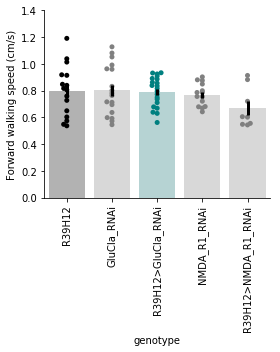

In [9]:
# Extended Data Fig. 10b:
# Calculate mean forward walking velocity:
data2_R39H12_barfixation_forward = data2_R39H12_barfixation_ordered.reset_index().set_index(['ordered_index', 
                            'genotype', 'flyname', 'time',]).groupby(level=['ordered_index', 
                            'genotype', 'flyname']).mean().drop(columns=['trial', 'rotation', 'bar_angle', 'trials_n']).reset_index()

bpal = ['k', 'gray', 'teal', 'gray', 'gray']
dotsize = 5

fig, ax = plt.subplots(1, 1, figsize=(4, 5))
a = sns.swarmplot(x="genotype", y="forward", hue="genotype", palette=bpal,
                  data=data2_R39H12_barfixation_forward, dodge=False, alpha=1.0, size=dotsize)
a.legend_.remove()
b = sns.barplot(x="genotype", y="forward", hue="genotype", palette=bpal,
                data=data2_R39H12_barfixation_forward, dodge=False, ci=None, alpha=.3);
b.errorbar(x=np.arange(0, len(data2_R39H12_barfixation_forward.genotype.unique())),y=data2_R39H12_barfixation_forward.groupby(['genotype'], sort=False).mean().forward,
             yerr=data2_R39H12_barfixation_forward.groupby(['genotype'], sort=False).sem().forward, fmt='none', c='k', zorder=3, elinewidth=3)
b.legend_.remove()

ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.set_ylabel('Forward walking speed (cm/s)')
ax.set_ylim([0, 1.4])

sns.despine()
plt.tight_layout();
#plt.savefig('edfig10b.pdf');

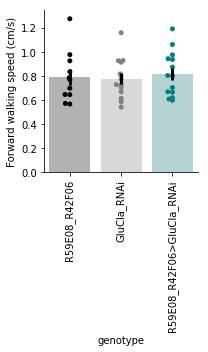

In [10]:
# Extended Data Fig. 10d:
# Calculate mean forward walking velocity:
data3_R59E08_R42F06_barfixation_forward = data3_R59E08_R42F06_barfixation_ordered.reset_index().set_index(['ordered_index', 
                            'genotype', 'flyname', 'time',]).groupby(level=['ordered_index', 
                            'genotype', 'flyname']).mean().drop(columns=['trial', 'rotation', 'bar_angle', 'trials_n']).reset_index()

bpal = ['k', 'gray', 'teal']
dotsize = 5

fig, ax = plt.subplots(1, 1, figsize=(3, 5))
a = sns.swarmplot(x="genotype", y="forward", hue="genotype", palette=bpal,
                  data=data3_R59E08_R42F06_barfixation_forward, dodge=False, alpha=1.0, size=dotsize)
a.legend_.remove()
b = sns.barplot(x="genotype", y="forward", hue="genotype", palette=bpal,
                data=data3_R59E08_R42F06_barfixation_forward, dodge=False, ci=None, alpha=.3);
b.errorbar(x=np.arange(0, len(data3_R59E08_R42F06_barfixation_forward.genotype.unique())),y=data3_R59E08_R42F06_barfixation_forward.groupby(['genotype'], sort=False).mean().forward,
             yerr=data3_R59E08_R42F06_barfixation_forward.groupby(['genotype'], sort=False).sem().forward, fmt='none', c='k', zorder=3, elinewidth=3)
b.legend_.remove()

ax.set_xticklabels(ax.get_xticklabels(), rotation = 90)
ax.set_ylabel('Forward walking speed (cm/s)')

sns.despine()
plt.tight_layout();
#plt.savefig('edfig10f.pdf');